In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# ML Libraries
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_theme(style="whitegrid")

In [12]:
# Load dataset
df = pd.read_csv("/content/diabetes.csv")

# List of features where 0 represents missing/invalid physiological data
zero_features = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Replace invalid 0s with NaN
df[zero_features] = df[zero_features].replace(0, np.nan)

# Verify missing value counts
print("Missing values per column after replacing 0s:")
print(df[zero_features].isnull().sum())

Missing values per column after replacing 0s:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


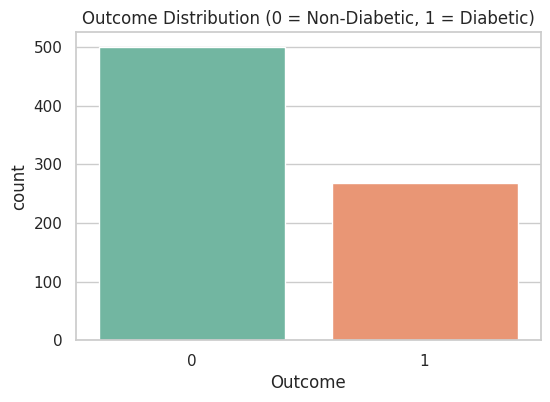

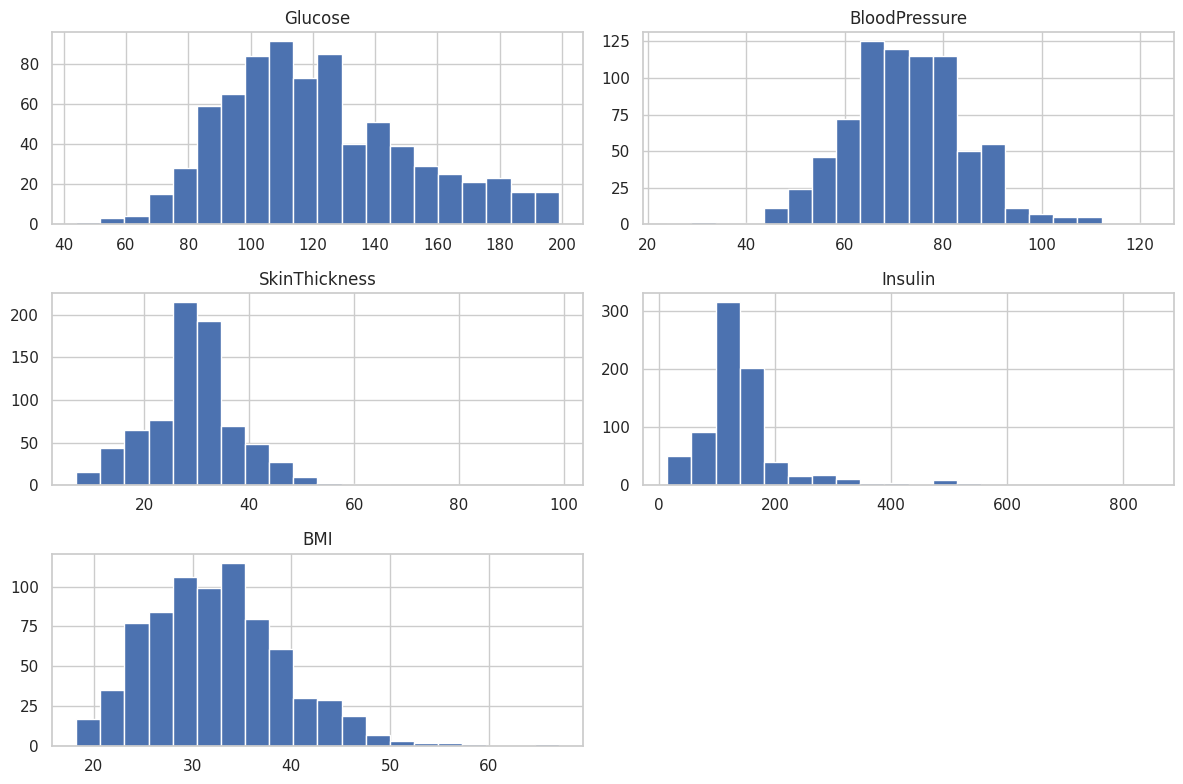

In [13]:
# Summary statistics including missing values
display(df.describe())

# Target class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Outcome', data=df, palette='Set2')
plt.title('Outcome Distribution (0 = Non-Diabetic, 1 = Diabetic)')
plt.show()

# Distribution of features before/after missing value context
df[zero_features].hist(bins=20, figsize=(12, 8))
plt.tight_layout()
plt.show()



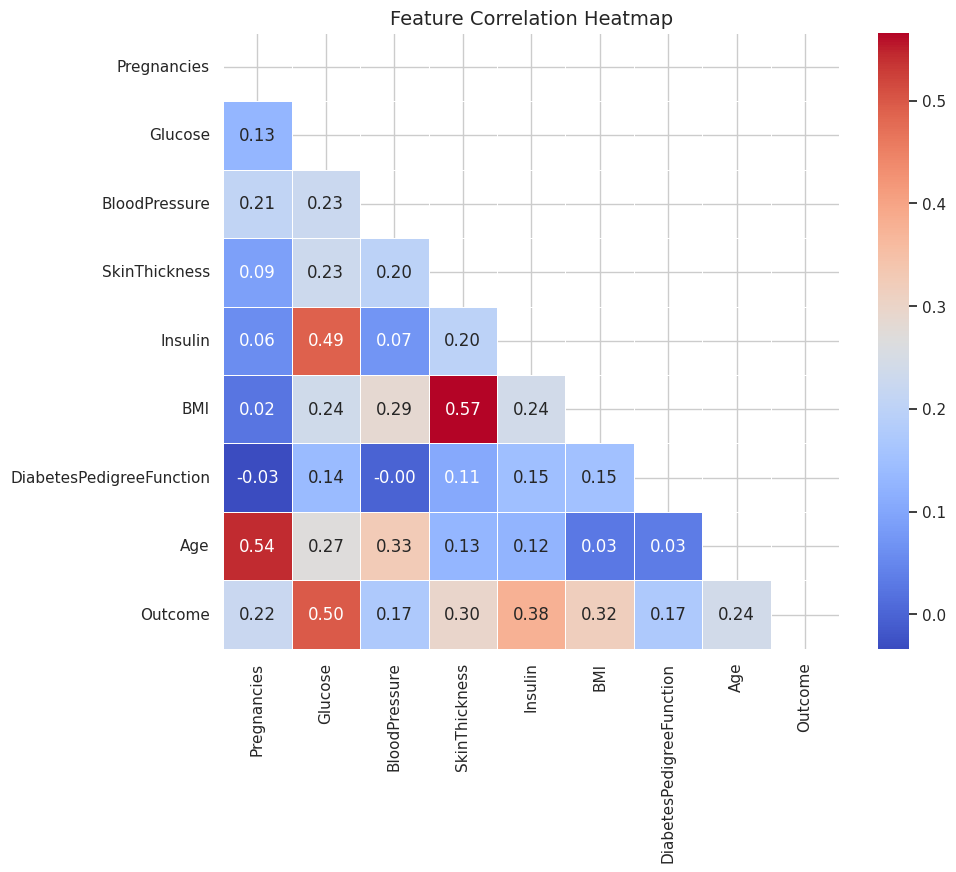

In [14]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Plot heatmap
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5,
    mask=mask
)
plt.title("Feature Correlation Heatmap", fontsize=14)
plt.show()

In [15]:
# Separate Features and Target
X = df.drop(columns=['Outcome'])
y = df['Outcome']

# 1. Train-Test Split (80% Train, 20% Test with Stratification)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 2. Impute Missing Values (using median to prevent influence of outliers)
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# 3. Feature Scaling (Standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# Convert back to DataFrame for readability
X_train_prep = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_prep = pd.DataFrame(X_test_scaled, columns=X.columns)

In [16]:
# Initialize models
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# Dictionary to hold results
results = []

for name, model in models.items():
    # Train
    model.fit(X_train_prep, y_train)

    # Predict
    y_pred = model.predict(X_test_prep)
    y_proba = model.predict_proba(X_test_prep)[:, 1] if hasattr(model, "predict_proba") else None

    # Evaluate
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred) # Recall is vital to minimize false negatives in diagnosis
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan

    results.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4),
        "ROC-AUC": round(roc_auc, 4)
    })

# Performance Summary Table
results_df = pd.DataFrame(results)
display(results_df)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.7078,0.5882,0.5556,0.5714,0.8263
1,Random Forest,0.8636,0.8113,0.7963,0.8037,0.9447


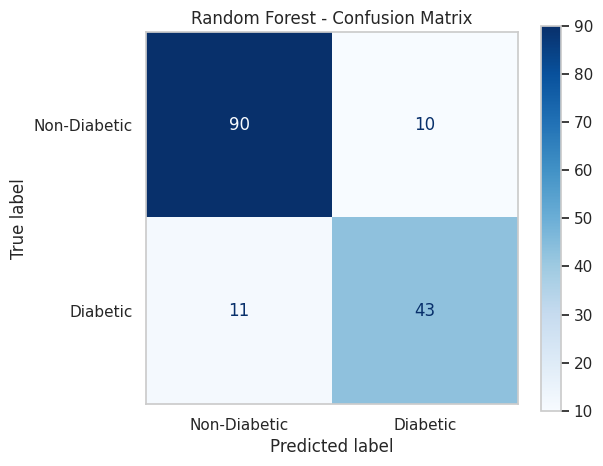


--- Detailed Classification Report (Random Forest) ---
              precision    recall  f1-score   support

Non-Diabetic       0.89      0.90      0.90       100
    Diabetic       0.81      0.80      0.80        54

    accuracy                           0.86       154
   macro avg       0.85      0.85      0.85       154
weighted avg       0.86      0.86      0.86       154



In [17]:
# Visualize Confusion Matrix for Random Forest Model
rf_model = models["Random Forest"]
y_pred_rf = rf_model.predict(X_test_prep)

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Diabetic', 'Diabetic'])
disp.plot(cmap='Blues', ax=ax)
plt.title('Random Forest - Confusion Matrix')
plt.grid(False)
plt.show()

print("\n--- Detailed Classification Report (Random Forest) ---")
print(classification_report(y_test, y_pred_rf, target_names=['Non-Diabetic', 'Diabetic']))

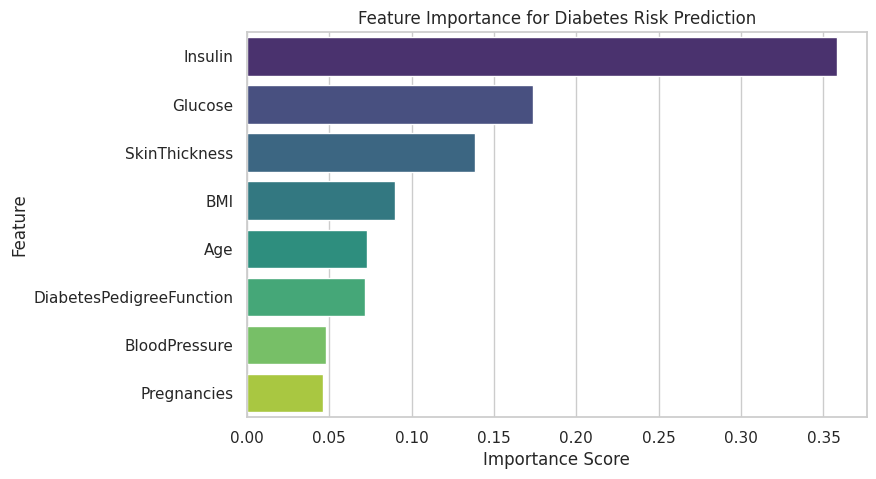

In [18]:
# Extract Feature Importances from Random Forest
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot Feature Importances
plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Feature Importance for Diabetes Risk Prediction')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()